## ***Innomatics Research Labs : Data Science with Gen AI Internship***

*Below **"Sentiment Analysis of Real-time Flipkart Product
Reviews (YONEX MAVIS 350 Nylon Shuttle)"** done by Deepak Kaura*

### *Objective-*

The objective of this project is to classify customer reviews as positive or negative and understand the pain points of customers who write negative reviews. By analyzing the sentiment of reviews, we aim to gain insights into product features that contribute to customer satisfaction or dissatisfaction.

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

import joblib

nltk.download("stopwords",quiet = True)
nltk.download("wordnet",quiet = True)



True

In [2]:
df = pd.read_csv("data.csv")

df.head(8)

,Reviewer Name,Review Title,Place of Review,Up Votes,Down Votes,Month,Review text,Ratings
0,Kamal Suresh,Nice product,"Certified Buyer, Chirakkal",889.0,64.0,Feb 2021,"Nice product, good quality, but price is now r...",4
1,Flipkart Customer,Don't waste your money,"Certified Buyer, Hyderabad",109.0,6.0,Feb 2021,They didn't supplied Yonex Mavis 350. Outside ...,1
2,A. S. Raja Srinivasan,Did not meet expectations,"Certified Buyer, Dharmapuri",42.0,3.0,Apr 2021,Worst product. Damaged shuttlecocks packed in ...,1
3,Suresh Narayanasamy,Fair,"Certified Buyer, Chennai",25.0,1.0,NaN,"Quite O. K. , but nowadays the quality of the...",3
4,ASHIK P A,Over priced,NaN,147.0,24.0,Apr 2016,Over pricedJust â?¹620 ..from retailer.I didn'...,1
5,Baji Sankar,Mind-blowing purchase,"Certified Buyer, Hyderabad",173.0,45.0,Oct 2018,Good quality product. Delivered on time.READ MORE,5
6,Flipkart Customer,Must buy!,"Certified Buyer, Doom Dooma",403.0,121.0,Jan 2020,BEST PURCHASE It is a good quality and is more...,5
7,Flipkart Customer,Classy product,"Certified Buyer, Panjim",59.0,13.0,Oct 2018,Good quality original shuttles.READ MORE,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8518 entries, 0 to 8517
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Reviewer Name    8508 non-null   object 
 1   Review Title     8508 non-null   object 
 2   Place of Review  8468 non-null   object 
 3   Up Votes         8508 non-null   float64
 4   Down Votes       8508 non-null   float64
 5   Month            8053 non-null   object 
 6   Review text      8510 non-null   object 
 7   Ratings          8518 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 532.5+ KB


In [ ]:
df.isnull().sum()

,0
Reviewer Name,10
Review Title,10
Place of Review,50
Up Votes,10
Down Votes,10
Month,465
Review text,8
Ratings,0


In [3]:
# Remove neutral reviews
df = df[df["Ratings"] != 3]

# Create sentiment label
df["sentiment"] = df["Ratings"].apply(lambda x: 1 if x >= 4 else 0)

# Combine title and review text
df["text"] = df["Review Title"].fillna("") + " " + df["Review text"].fillna("")
df = df[["text", "sentiment"]]
df.head()

,text,sentiment
0,"Nice product Nice product, good quality, but p...",1
1,Don't waste your money They didn't supplied Yo...,0
2,Did not meet expectations Worst product. Damag...,0
4,Over priced Over pricedJust â?¹620 ..from reta...,0
5,Mind-blowing purchase Good quality product. De...,1


In [4]:
stop_words = set(stopwords.words("english")) - {"not", "no", "never"}
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [5]:
df["processed_text"] = df["text"].apply(preprocess)
df.head()

,text,sentiment,processed_text
0,"Nice product Nice product, good quality, but p...",1,nice product nice product good quality price r...
1,Don't waste your money They didn't supplied Yo...,0,dont waste money didnt supplied yonex mavis ou...
2,Did not meet expectations Worst product. Damag...,0,not meet expectation worst product damaged shu...
4,Over priced Over pricedJust â?¹620 ..from reta...,0,priced pricedjust retaileri didnt understand w...
5,Mind-blowing purchase Good quality product. De...,1,mindblowing purchase good quality product deli...


In [ ]:
df.shape

(7903, 3)

In [ ]:
df.columns

Index(['text', 'sentiment', 'processed_text'], dtype='object')

In [6]:
df[['text','processed_text', 'sentiment']]

,text,processed_text,sentiment
0,"Nice product Nice product, good quality, but p...",nice product nice product good quality price r...,1
1,Don't waste your money They didn't supplied Yo...,dont waste money didnt supplied yonex mavis ou...,0
2,Did not meet expectations Worst product. Damag...,not meet expectation worst product damaged shu...,0
4,Over priced Over pricedJust â?¹620 ..from reta...,priced pricedjust retaileri didnt understand w...,0
5,Mind-blowing purchase Good quality product. De...,mindblowing purchase good quality product deli...,1
...,...,...,...
8513,,,1
8514,,,0
8515,,,1
8516,,,0


In [ ]:
df.isnull().sum()

,0
text,0
sentiment,0
processed_text,0


In [7]:
from sklearn.model_selection import train_test_split
#from imblearn.over_sampling import SMOTE

X = df[['text','processed_text']]

y = df['sentiment']



In [ ]:
y.value_counts()

,count
sentiment,
1,6826
0,1077


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [9]:
train_df = X_train.copy()
train_df['sentiment'] = y_train.values

test_df = X_test.copy()
test_df['sentiment'] = y_test.values

In [1]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-j5pkypeu
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-j5pkypeu
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other 

In [10]:
from pycaret.classification import *

s = setup(
    data=train_df,
    target='sentiment',
    test_data=test_df,
    fold_strategy='stratifiedkfold',
    fold=5,
    session_id=42)

,Description,Value
0,Session id,42
1,Target,sentiment
2,Target type,Binary
3,Original data shape,"(7903, 3)"
4,Transformed data shape,"(7903, 3)"
5,Transformed train set shape,"(6717, 3)"
6,Transformed test set shape,"(1186, 3)"
7,Categorical features,2
8,Preprocess,True
9,Imputation type,simple


In [11]:
# functional API
best = compare_models(sort='F1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.8651,0.6919,0.9959,0.8676,0.9273,0.0527,0.1193,0.0820
lr,Logistic Regression,0.8644,0.6922,0.9988,0.8651,0.9271,0.0184,0.0697,1.3780
dummy,Dummy Classifier,0.8638,0.5000,1.0000,0.8638,0.9269,0.0000,0.0000,0.0680
knn,K Neighbors Classifier,0.8639,0.5654,0.9979,0.8652,0.9268,0.0205,0.0680,0.1440
rf,Random Forest Classifier,0.8638,0.6081,0.9978,0.8652,0.9268,0.0202,0.0659,0.3260
gbc,Gradient Boosting Classifier,0.8638,0.6513,0.9978,0.8652,0.9268,0.0202,0.0666,0.3400
nb,Naive Bayes,0.8636,0.5155,0.9976,0.8652,0.9267,0.0199,0.0635,0.0700
ridge,Ridge Classifier,0.8636,0.6911,0.9976,0.8652,0.9267,0.0199,0.0635,0.0760
lightgbm,Light Gradient Boosting Machine,0.8635,0.6598,0.9974,0.8652,0.9266,0.0196,0.0614,0.2260
dt,Decision Tree Classifier,0.8633,0.6448,0.9972,0.8651,0.9265,0.0193,0.0597,0.0740


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [14]:
gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8646,0.6993,0.9991,0.8650,0.9273,0.0172,0.0732
1,0.8616,0.6296,0.9957,0.8646,0.9255,0.0111,0.0316
2,0.8660,0.6106,0.9991,0.8662,0.9279,0.0356,0.1183
3,0.8622,0.6872,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8645,0.6298,0.9974,0.8660,0.9271,0.0324,0.0918
Mean,0.8638,0.6513,0.9978,0.8652,0.9268,0.0202,0.0666
Std,0.0016,0.0352,0.0013,0.0008,0.0009,0.0119,0.0372


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
tuned_gbc = tune_model(gbc, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8646,0.6988,0.9991,0.8650,0.9273,0.0172,0.0732
1,0.8646,0.6867,0.9991,0.8650,0.9273,0.0172,0.0732
2,0.8660,0.6940,0.9991,0.8662,0.9279,0.0356,0.1183
3,0.8622,0.6919,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8652,0.6777,0.9983,0.8661,0.9275,0.0340,0.1036
Mean,0.8645,0.6898,0.9986,0.8653,0.9272,0.0218,0.0773
Std,0.0012,0.0072,0.0007,0.0008,0.0007,0.0115,0.0344


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [16]:
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8638,0.6668,0.9983,0.8649,0.9268,0.0157,0.0580
1,0.8616,0.5907,0.9957,0.8646,0.9255,0.0111,0.0316
2,0.8660,0.5957,0.9991,0.8662,0.9279,0.0356,0.1183
3,0.8622,0.5886,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8652,0.5987,0.9983,0.8661,0.9275,0.0340,0.1036
Mean,0.8638,0.6081,0.9978,0.8652,0.9268,0.0202,0.0659
Std,0.0017,0.0296,0.0012,0.0008,0.0009,0.0124,0.0392


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
tuned_rf = tune_model(rf, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8638,0.6977,0.9983,0.8649,0.9268,0.0157,0.0580
1,0.8616,0.6585,0.9957,0.8646,0.9255,0.0111,0.0316
2,0.8660,0.6651,0.9991,0.8662,0.9279,0.0356,0.1183
3,0.8622,0.6486,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8652,0.6543,0.9983,0.8661,0.9275,0.0340,0.1036
Mean,0.8638,0.6649,0.9978,0.8652,0.9268,0.0202,0.0659
Std,0.0017,0.0173,0.0012,0.0008,0.0009,0.0124,0.0392


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [12]:
svm = create_model('svm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8653,0.6988,0.9974,0.8668,0.9275,0.0414,0.1103
1,0.8631,0.6901,0.9940,0.8670,0.9262,0.0440,0.0938
2,0.8660,0.6947,0.9966,0.8679,0.9278,0.0576,0.1325
3,0.8622,0.6945,0.9940,0.8663,0.9257,0.0351,0.0776
4,0.8690,0.6812,0.9974,0.8699,0.9293,0.0855,0.1824
Mean,0.8651,0.6919,0.9959,0.8676,0.9273,0.0527,0.1193
Std,0.0024,0.0060,0.0016,0.0013,0.0013,0.0180,0.0364


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [13]:
tuned_svm = tune_model(svm, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8653,0.6996,0.9974,0.8668,0.9275,0.0414,0.1103
1,0.8631,0.6902,0.9940,0.8670,0.9262,0.0440,0.0938
2,0.8660,0.6948,0.9966,0.8679,0.9278,0.0576,0.1325
3,0.8622,0.6945,0.9940,0.8663,0.9257,0.0351,0.0776
4,0.8690,0.6820,0.9974,0.8699,0.9293,0.0855,0.1824
Mean,0.8651,0.6922,0.9959,0.8676,0.9273,0.0527,0.1193
Std,0.0024,0.0059,0.0016,0.0013,0.0013,0.0180,0.0364


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [18]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8638,0.6996,0.9991,0.8644,0.9269,0.0079,0.0410
1,0.8646,0.6902,0.9991,0.8650,0.9273,0.0172,0.0732
2,0.8652,0.6948,0.9991,0.8656,0.9276,0.0264,0.0978
3,0.8622,0.6945,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8660,0.6820,0.9991,0.8662,0.9279,0.0356,0.1183
Mean,0.8644,0.6922,0.9988,0.8651,0.9271,0.0184,0.0697
Std,0.0013,0.0059,0.0007,0.0008,0.0007,0.0114,0.0365


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [19]:
tuned_lr = tune_model(lr, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8653,0.6996,0.9974,0.8668,0.9275,0.0414,0.1103
1,0.8631,0.6902,0.9940,0.8670,0.9262,0.0440,0.0938
2,0.8660,0.6948,0.9966,0.8679,0.9278,0.0576,0.1325
3,0.8622,0.6945,0.9940,0.8663,0.9257,0.0351,0.0776
4,0.8690,0.6820,0.9974,0.8699,0.9293,0.0855,0.1824
Mean,0.8651,0.6922,0.9959,0.8676,0.9273,0.0527,0.1193
Std,0.0024,0.0059,0.0016,0.0013,0.0013,0.0180,0.0364


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [20]:
knn = create_model('knn')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8624,0.6754,0.9966,0.8647,0.9260,0.0126,0.0385
1,0.8646,0.5016,0.9991,0.8650,0.9273,0.0172,0.0732
2,0.8660,0.6467,0.9991,0.8662,0.9279,0.0356,0.1183
3,0.8622,0.4946,0.9974,0.8641,0.9260,0.0049,0.0181
4,0.8645,0.5088,0.9974,0.8660,0.9271,0.0324,0.0918
Mean,0.8639,0.5654,0.9979,0.8652,0.9268,0.0205,0.0680
Std,0.0014,0.0788,0.0010,0.0008,0.0008,0.0117,0.0360


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [21]:
tuned_knn = tune_model(knn, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8661,0.6999,0.9983,0.8669,0.9279,0.0430,0.1220
1,0.8661,0.6858,0.9974,0.8674,0.9279,0.0504,0.1270
2,0.8660,0.6923,0.9966,0.8679,0.9278,0.0576,0.1325
3,0.8622,0.6575,0.9940,0.8663,0.9257,0.0351,0.0776
4,0.8690,0.6331,0.9974,0.8699,0.9293,0.0855,0.1824
Mean,0.8659,0.6737,0.9967,0.8677,0.9277,0.0543,0.1283
Std,0.0021,0.0249,0.0015,0.0012,0.0011,0.0173,0.0333


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


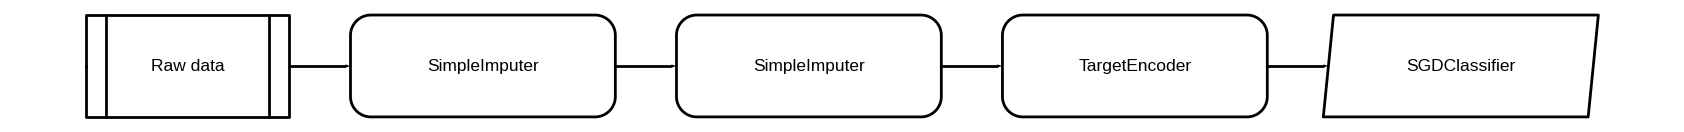




_________________________________________   confusion_matrix   ___________________________________________


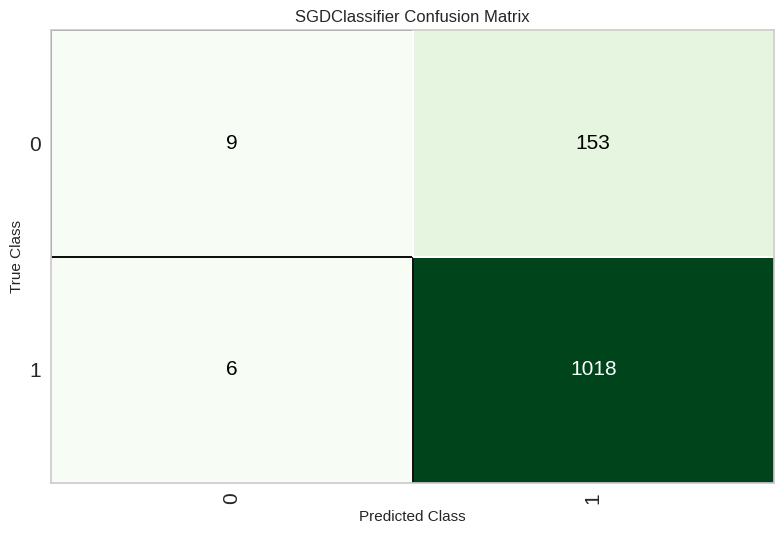




_________________________________________   error   ___________________________________________


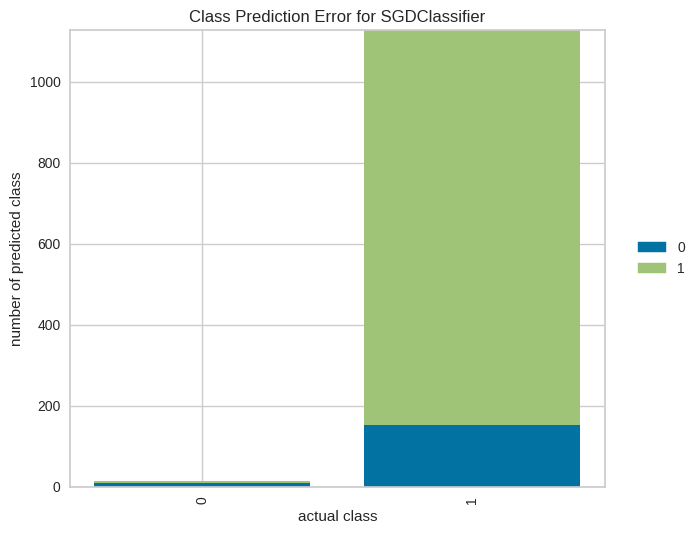




_________________________________________   class_report   ___________________________________________


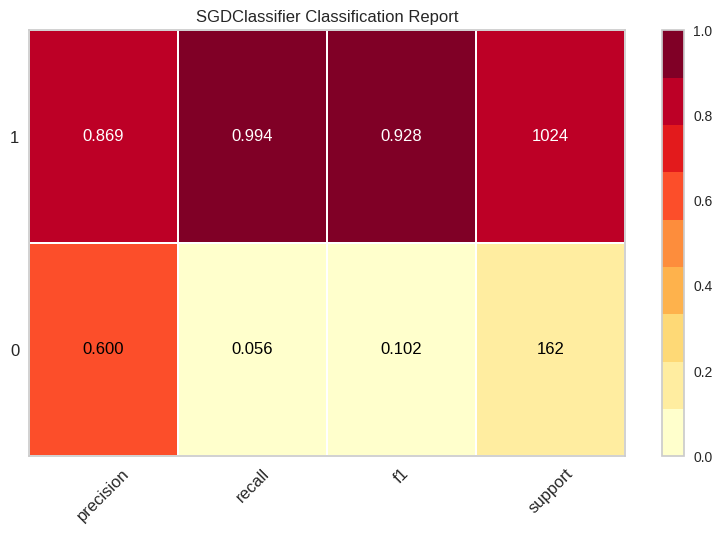




_________________________________________   feature_all   ___________________________________________


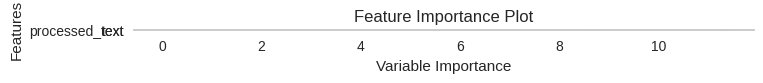




_________________________________________   parameter   ___________________________________________


,Parameters
alpha,0.0001
average,False
class_weight,None
early_stopping,False
epsilon,0.1
eta0,0.001
fit_intercept,True
l1_ratio,0.15
learning_rate,optimal
loss,hinge


In [ ]:
available_plots = ['pipeline','confusion_matrix','error','class_report','feature_all','parameter']

for i in available_plots:
    print('_________________________________________  ',i,'  ___________________________________________',sep=' ')
    plot_model(tuned_svm,plot=i)
    print('\n\n')

In [22]:
predict_knn = predict_model(tuned_knn)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.8600,0.6985,0.9941,0.8642,0.9246,0.0108,0.0272


In [23]:
predict_rf = predict_model(tuned_rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8617,0.6073,0.9961,0.8644,0.9256,0.0142,0.0409


In [24]:
predict_lr = predict_model(tuned_lr)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8659,0.6996,0.9941,0.8693,0.9276,0.0804,0.1527


In [25]:
predict_svm = predict_model(tuned_svm)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,SVM - Linear Kernel,0.8659,0.5248,0.9941,0.8693,0.9276,0.0804,0.1527


In [26]:
predict_gbc = predict_model(tuned_gbc)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8617,0.7003,0.9961,0.8644,0.9256,0.0142,0.0409


In [27]:
predict_svm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1186 entries, 3822 to 7243
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              1186 non-null   object
 1   processed_text    1186 non-null   object
 2   sentiment         1186 non-null   int8  
 3   prediction_label  1186 non-null   int64 
dtypes: int64(1), int8(1), object(2)
memory usage: 38.2+ KB


In [28]:
predictions = predict_svm.drop('sentiment', axis=1)


In [ ]:
joblib.dump(predict_svm, "SVM_sentiment_model.pkl")


print("\n✅ Model saved successfully")


✅ Model saved successfully


In [29]:
predictions.head()

,text,processed_text,prediction_label
3822,Highly recommended Very niceREAD MORE,highly recommended niceread,1
4095,Worth the money Happy because I got it for rea...,worth money happy got reasonable price hope ge...,1
1648,Terrific purchase GoodREAD MORE,terrific purchase goodread,1
8473,Don't waste your money Shuttles were awsm as I...,dont waste money shuttle awsm played also deli...,1
7450,Really Nice very fastREAD MORE,really nice fastread,1


In [33]:
# Filter rows where Predicted is 'Positive'
df_positive = predictions[predictions['prediction_label'] == 1]

# Select only Processed Text column
case1_info = df_positive[['processed_text',	'prediction_label']]

case1_info.head()

,processed_text,prediction_label
3822,highly recommended niceread,1
4095,worth money happy got reasonable price hope ge...,1
1648,terrific purchase goodread,1
8473,dont waste money shuttle awsm played also deli...,1
7450,really nice fastread,1


In [34]:
# Filter rows where Predicted is 'Negative'
df_negative = predictions[predictions['prediction_label'] == 0]

# Select only Processed Text column
case2_info = df_negative[['processed_text',	'prediction_label']]

case2_info.head()

,processed_text,prediction_label
6863,pretty good niceread,0
2923,terrific purchase badread,0
5034,nice product not goodread,0
342,poor bad qualityread,0
52,unsatisfactory worstread,0


In [35]:
predictions.to_csv('Test data of Flipkart YONEX.csv', index=False)

In [ ]:
# ===============================
# 1. Imports
# ===============================
import ipywidgets as widgets
from IPython.display import display, clear_output

# ===============================
# 2. Dropdown to select processed_text
# ===============================
processed_text_dropdown = widgets.Dropdown(
    options=[
        (f"Text {i}", i) for i in predictions['processed_text'].index
    ],
    description="Select Text:",
    style={'description_width': 'initial'}
)

# ===============================
# 3. Output area
# ===============================
output = widgets.Output()

# ===============================
# 4. Display processed_text + sentiment
# ===============================
def show_processed_text_prediction(change=None):
    with output:
        clear_output()

        row = predictions.loc[processed_text_dropdown.value]

        sentiment = "🟢 Positive" if row['prediction_label'] == 1 else "🔴 Negative"

        print("Processed Text:")
        print("-" * 60)
        print(row['processed_text'])
        print("\nSentiment Prediction:", sentiment)

# ===============================
# 5. Attach event
# ===============================
processed_text_dropdown.observe(show_processed_text_prediction, names='value')

# ===============================
# 6. Display UI
# ===============================
display(processed_text_dropdown, output)


Dropdown(description='Select Text:', options=(('Text 3822', 3822), ('Text 4095', 4095), ('Text 1648', 1648), (…

Output()